# N-BEATS — Walmart Store Sales Forecasting

**Doubly-residual topology:**
```
input → [Block₁] → residual₁ → [Block₂] → residual₂ → ...
              ↓                      ↓
          forecast₁ +         forecast₂ + ... = final forecast
```

### Two variants
1. **Generic N-BEATS** — learns unconstrained basis from data
2. **Interpretable N-BEATS** — enforces polynomial (trend) and Fourier (seasonality) bases,
   giving a clean trend/seasonality decomposition


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import mlflow
import mlflow.pytorch

from mlflow_setup import init_mlflow

from sklearn.base import BaseEstimator, RegressorMixin

from features import load_raw_data, merge_all, build_all_features, BASE_FEATURES, TARGET
from wmae import wmae

DATA_DIR    = "."
RANDOM_SEED = 42
HORIZON     = 13   # forecast 13 weeks ahead
INPUT_SIZE  = 52   # look-back window: 1 year
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"MLflow version  : {mlflow.__version__}")

print("imports OK")

PyTorch version : 2.6.0+cu124
Device          : cuda
MLflow version  : 3.14.0
imports OK


---
## 1. N-BEATS Architecture (from scratch)


In [18]:
class NBeatsBlock(nn.Module):
    """
    Single N-BEATS block.

    Architecture:
      input (T,) → FC stack → hidden
                              → theta_b (backcast coefficients)
                              → theta_f (forecast coefficients)
      backcast = basis_b @ theta_b   shape (T,)
      forecast = basis_f @ theta_f   shape (H,)
    """

    def __init__(self, input_size, horizon, hidden_units, n_layers, theta_b_size, theta_f_size,
                 basis_b, basis_f):
        super().__init__()
        self.basis_b = basis_b   # (theta_b_size, T) matrix
        self.basis_f = basis_f   # (theta_f_size, H) matrix

        # shared FC stack
        layers = [nn.Linear(input_size, hidden_units), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_units, hidden_units), nn.ReLU()]
        self.fc = nn.Sequential(*layers)

        self.theta_b_proj = nn.Linear(hidden_units, theta_b_size, bias=False)
        self.theta_f_proj = nn.Linear(hidden_units, theta_f_size, bias=False)

    def forward(self, x):
        """
        x : (batch, T)
        returns backcast (batch, T), forecast (batch, H)
        """
        h        = self.fc(x)                           # (batch, hidden)
        theta_b  = self.theta_b_proj(h)                 # (batch, theta_b_size)
        theta_f  = self.theta_f_proj(h)                 # (batch, theta_f_size)
        # basis_b/basis_f have shape (n_theta, length); contract over n_theta
        # (theta's own dim), broadcasting to the basis's length dim (T or H).
        backcast = torch.einsum('bn,nt->bt', theta_b, self.basis_b)  # (batch, T)
        forecast = torch.einsum('bn,nt->bt', theta_f, self.basis_f)  # (batch, H)
        return backcast, forecast


def generic_basis(size, n_theta, device):
    """Identity basis — theta IS the output (unconstrained)."""
    return torch.eye(n_theta, size, device=device)   # shape (n_theta, size)


def fourier_basis(horizon, n_harmonics, device):
    """Seasonal Fourier basis matrix. shape: (n_harmonics*2, horizon)"""
    t = torch.arange(horizon, dtype=torch.float32, device=device) / horizon
    freqs = torch.arange(1, n_harmonics + 1, dtype=torch.float32, device=device)
    cos_t = torch.cos(2 * np.pi * freqs[:, None] * t[None, :])  # (n_harmonics, H)
    sin_t = torch.sin(2 * np.pi * freqs[:, None] * t[None, :])  # (n_harmonics, H)
    return torch.cat([cos_t, sin_t], dim=0)                      # (2*n_harmonics, H)


def polynomial_basis(horizon, degree, device):
    """Trend polynomial basis matrix. shape: (degree+1, horizon)"""
    t = torch.arange(horizon, dtype=torch.float32, device=device) / (horizon - 1)
    return torch.stack([t ** i for i in range(degree + 1)], dim=0)  # (degree+1, H)


print("N-BEATS block definitions ready.")

N-BEATS block definitions ready.


In [19]:
class NBeats(nn.Module):
    """
    Full N-BEATS model.

    Parameters
    ----------
    input_size  : look-back window T
    horizon     : forecast steps H
    stack_types : list of 'generic' | 'trend' | 'seasonality'
    n_blocks_per_stack : number of blocks in each stack
    hidden_units : FC layer width
    n_layers     : FC layers per block
    n_harmonics  : Fourier harmonics (seasonality stack)
    poly_degree  : polynomial degree (trend stack)
    """

    def __init__(self, input_size, horizon,
                 stack_types=('generic', 'generic'),
                 n_blocks_per_stack=3,
                 hidden_units=512,
                 n_layers=4,
                 n_harmonics=2,
                 poly_degree=2,
                 device=torch.device('cpu')):
        super().__init__()
        self.input_size = input_size
        self.horizon    = horizon
        self.dev        = device

        self.blocks = nn.ModuleList()
        for stack_type in stack_types:
            for _ in range(n_blocks_per_stack):
                if stack_type == 'generic':
                    theta_b = min(input_size, hidden_units // 2)
                    theta_f = min(horizon,    hidden_units // 2)
                    basis_b = generic_basis(input_size, theta_b, device)
                    basis_f = generic_basis(horizon,    theta_f, device)
                elif stack_type == 'seasonality':
                    theta_b = 2 * n_harmonics
                    theta_f = 2 * n_harmonics
                    basis_f = fourier_basis(horizon,    n_harmonics, device)
                    basis_b = fourier_basis(input_size, n_harmonics, device)
                elif stack_type == 'trend':
                    theta_b = poly_degree + 1
                    theta_f = poly_degree + 1
                    basis_f = polynomial_basis(horizon,    poly_degree, device)
                    basis_b = polynomial_basis(input_size, poly_degree, device)
                else:
                    raise ValueError(f"Unknown stack_type: {stack_type}")

                block = NBeatsBlock(
                    input_size, horizon, hidden_units, n_layers,
                    theta_b, theta_f, basis_b, basis_f
                )
                self.blocks.append(block)

    def forward(self, x):
        """
        x        : (batch, T)  — normalised look-back window
        returns  : forecast (batch, H)
        """
        residual = x
        total_forecast = torch.zeros(x.shape[0], self.horizon, device=self.dev)

        for block in self.blocks:
            backcast, forecast = block(residual)
            residual           = residual - backcast
            total_forecast     = total_forecast + forecast

        return total_forecast


# quick architecture sanity check
_model = NBeats(input_size=INPUT_SIZE, horizon=HORIZON, device=DEVICE).to(DEVICE)
_x     = torch.randn(4, INPUT_SIZE).to(DEVICE)
_out   = _model(_x)
print(f"N-BEATS output shape: {_out.shape}  (expected: (4, {HORIZON}))")
n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
del _model, _x, _out

N-BEATS output shape: torch.Size([4, 13])  (expected: (4, 13))
Trainable parameters: 5,090,304


---
## 2. Data Loading & Preparation

In [20]:
train_raw, test_raw, features_raw, stores_raw = load_raw_data(DATA_DIR)
train_merged, test_merged = merge_all(train_raw.copy(), test_raw.copy(), features_raw, stores_raw)
train_merged = train_merged[train_merged.Weekly_Sales >= 0].reset_index(drop=True)

# create per-series dataframes sorted by date
train_merged = train_merged.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

# filter series too short for INPUT_SIZE + HORIZON
series_lengths = train_merged.groupby(['Store', 'Dept'])['Date'].count()
valid_pairs    = series_lengths[series_lengths >= INPUT_SIZE + HORIZON + 5].index
train_filtered = train_merged[
    train_merged.set_index(['Store', 'Dept']).index.isin(valid_pairs)
].reset_index(drop=True)

print(f"Total series   : {series_lengths.shape[0]}")
print(f"Valid series   : {len(valid_pairs)}")
print(f"Rows (filtered): {len(train_filtered):,}")

Total series   : 3323
Valid series   : 2949
Rows (filtered): 413,346


In [21]:
class WalmartWindowDataset(Dataset):
    """
    Sliding-window dataset.

    For each (Store, Dept) series we extract all windows of length
    INPUT_SIZE + HORIZON, normalise each window by its mean (instance normalisation),
    and return:
      x   : (INPUT_SIZE,)  — input window (normalised)
      y   : (HORIZON,)     — target forecast (normalised)
      scale : float        — per-window scale (for denormalisation at inference)
      is_holiday: (HORIZON,) — holiday flag for WMAE
    """

    def __init__(self, df, input_size, horizon, stride=1):
        self.samples = []
        self.input_size = input_size
        self.horizon    = horizon

        for (store, dept), group in df.groupby(['Store', 'Dept']):
            group = group.sort_values('Date').reset_index(drop=True)
            sales = group['Weekly_Sales'].values.astype(np.float32)
            hols  = group['IsHoliday'].values.astype(np.float32)
            n     = len(sales)

            for start in range(0, n - input_size - horizon + 1, stride):
                x_raw = sales[start : start + input_size]
                y_raw = sales[start + input_size : start + input_size + horizon]
                h_win = hols[start + input_size : start + input_size + horizon]

                # instance normalisation: divide by mean of input window
                scale = x_raw.mean() if x_raw.mean() > 1 else 1.0
                x_norm = x_raw / scale
                y_norm = y_raw / scale

                self.samples.append((x_norm, y_norm, scale, h_win))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y, scale, hol = self.samples[idx]
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(scale, dtype=torch.float32),
                torch.tensor(hol, dtype=torch.float32))


# walk-forward split: val = last HORIZON weeks
cutoff_date  = sorted(train_filtered.Date.unique())[-HORIZON]
df_tr        = train_filtered[train_filtered.Date < cutoff_date].reset_index(drop=True)
df_val       = train_filtered[train_filtered.Date >= cutoff_date].reset_index(drop=True)

train_ds = WalmartWindowDataset(df_tr, INPUT_SIZE, HORIZON, stride=1)
print(f"Training windows : {len(train_ds):,}")
x0, y0, s0, h0 = train_ds[0]
print(f"x shape: {x0.shape}  y shape: {y0.shape}")

Training windows : 186,987
x shape: torch.Size([52])  y shape: torch.Size([13])


---
## 3. MLflow Initialisation

In [22]:
# Connect to DagsHub MLflow tracking server and select the experiment.
init_mlflow("NBEATS_Training")
print("MLflow ready.")

Initialized MLflow to track repo "sansi23/Walmart-Recruiting---Store-Sales-Forecasting"

Repository sansi23/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub connected: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
Experiment: NBEATS_Training
MLflow ready.


---
## 4. Training Loop

In [23]:
def train_nbeats(config, df_train, df_val_full, log_mlflow=True, run_name="NBEATS"):
    """
    Train an N-BEATS model, return (model, val_wmae).

    config keys:
      stack_types, n_blocks_per_stack, hidden_units, n_layers,
      n_harmonics, poly_degree, batch_size, lr, epochs, weight_decay

    Must be called inside an active `with mlflow.start_run(...):` block when
    log_mlflow=True — per-epoch train_loss/lr and the final val_wmae are logged
    to that run.
    """

    ds     = WalmartWindowDataset(df_train, INPUT_SIZE, HORIZON, stride=2)
    loader = DataLoader(ds, batch_size=config['batch_size'], shuffle=True,
                        num_workers=0, drop_last=True)

    model = NBeats(
        input_size=INPUT_SIZE,
        horizon=HORIZON,
        stack_types=config['stack_types'],
        n_blocks_per_stack=config['n_blocks_per_stack'],
        hidden_units=config['hidden_units'],
        n_layers=config['n_layers'],
        n_harmonics=config.get('n_harmonics', 2),
        poly_degree=config.get('poly_degree', 2),
        device=DEVICE,
    ).to(DEVICE)

    optimiser = torch.optim.AdamW(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config.get('weight_decay', 1e-4)
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=config['epochs']
    )

    history = {'train_loss': []}

    for epoch in range(1, config['epochs'] + 1):
        model.train()
        epoch_loss = 0.0
        for x_batch, y_batch, scale_batch, _ in loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimiser.zero_grad()
            pred = model(x_batch)                   # (batch, H)
            loss = F.l1_loss(pred, y_batch)         # MAE in normalised space
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(loader)
        history['train_loss'].append(avg_loss)

        if log_mlflow:
            mlflow.log_metric('train_loss', avg_loss, step=epoch)
            mlflow.log_metric('lr', scheduler.get_last_lr()[0], step=epoch)

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{config['epochs']}  loss={avg_loss:.4f}")

    # ---------- evaluate on validation set ----------
    model.eval()
    all_y_true, all_y_pred, all_hol = [], [], []

    for (store, dept), group in df_val_full.groupby(['Store', 'Dept']):
        group = group.sort_values('Date').reset_index(drop=True)
        sales = group['Weekly_Sales'].values.astype(np.float32)
        hols  = group['IsHoliday'].values.astype(np.float32)

        # find matching training tail to form the input window
        train_tail = (
            df_train[(df_train.Store == store) & (df_train.Dept == dept)]
            .sort_values('Date')['Weekly_Sales'].values.astype(np.float32)
        )
        if len(train_tail) < INPUT_SIZE:
            continue

        x_raw = train_tail[-INPUT_SIZE:]
        scale = x_raw.mean() if x_raw.mean() > 1 else 1.0
        x_in  = torch.tensor(x_raw / scale, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred_norm = model(x_in).squeeze(0).cpu().numpy()

        pred_sales = np.clip(pred_norm * scale, 0, None)
        n_val      = min(len(sales), HORIZON)

        all_y_true.extend(sales[:n_val].tolist())
        all_y_pred.extend(pred_sales[:n_val].tolist())
        all_hol.extend(hols[:n_val].tolist())

    val_wmae = wmae(np.array(all_y_true), np.array(all_y_pred), np.array(all_hol))

    if log_mlflow:
        mlflow.log_metric('val_wmae', val_wmae)

    print(f"  Val WMAE: {val_wmae:,.2f}")
    return model, val_wmae, history


print("Training function defined.")

Training function defined.


---
## 5. Baseline: Generic N-BEATS
MLflow run: `NBEATS_Baseline`

In [24]:
BASELINE_CONFIG = {
    'stack_types':       ('generic', 'generic'),
    'n_blocks_per_stack': 3,
    'hidden_units':       256,
    'n_layers':           4,
    'batch_size':         256,
    'lr':                 1e-3,
    'weight_decay':       1e-4,
    'epochs':             50,
}

print("Training Generic N-BEATS baseline...")
init_mlflow("NBEATS_Training")
with mlflow.start_run(run_name="NBEATS_Baseline") as run:
    mlflow.log_params({k: str(v) for k, v in BASELINE_CONFIG.items()})
    model_baseline, wmae_baseline, hist_baseline = train_nbeats(
        BASELINE_CONFIG, df_tr, df_val, log_mlflow=True, run_name="NBEATS_Generic_Baseline"
    )
    mlflow.log_metric('val_wmae', wmae_baseline)

print(f"Baseline WMAE: {wmae_baseline:,.2f}")

Training Generic N-BEATS baseline...


Initialized MLflow to track repo "sansi23/Walmart-Recruiting---Store-Sales-Forecasting"

Repository sansi23/Walmart-Recruiting---Store-Sales-Forecasting initialized!

DagsHub connected: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
Experiment: NBEATS_Training
  Epoch  10/50  loss=0.1504
  Epoch  20/50  loss=0.1291
  Epoch  30/50  loss=0.1087
  Epoch  40/50  loss=0.0928
  Epoch  50/50  loss=0.0873
  Val WMAE: 1,489.53
🏃 View run NBEATS_Baseline at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/b7e131de07c14983bca05f68f479c3b0
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5
Baseline WMAE: 1,489.53


---
## 6. Interpretable N-BEATS (Trend + Seasonality)
MLflow run: `NBEATS_Interpretable`

Stack 1 = **trend** (polynomial basis, degree 2)  
Stack 2 = **seasonality** (Fourier basis, 2 harmonics)

In [25]:
INTERP_CONFIG = {
    'stack_types':       ('trend', 'seasonality'),
    'n_blocks_per_stack': 3,
    'hidden_units':       256,
    'n_layers':           4,
    'n_harmonics':        4,    # Fourier harmonics
    'poly_degree':        2,    # polynomial degree for trend
    'batch_size':         256,
    'lr':                 1e-3,
    'weight_decay':       1e-4,
    'epochs':             50,
}

print("Training Interpretable N-BEATS...")
with mlflow.start_run(run_name="NBEATS_Interpretable") as run:
    mlflow.log_params({k: str(v) for k, v in INTERP_CONFIG.items()})
    model_interp, wmae_interp, hist_interp = train_nbeats(
        INTERP_CONFIG, df_tr, df_val, log_mlflow=True, run_name="NBEATS_Interpretable"
    )
    mlflow.log_metric('val_wmae', wmae_interp)

print(f"Interpretable WMAE: {wmae_interp:,.2f}")

Training Interpretable N-BEATS...
  Epoch  10/50  loss=0.1545
  Epoch  20/50  loss=0.1331
  Epoch  30/50  loss=0.1134
  Epoch  40/50  loss=0.1000
  Epoch  50/50  loss=0.0956
  Val WMAE: 1,556.81
🏃 View run NBEATS_Interpretable at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/c839e0cddece4b1db6e77517c1548cce
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5
Interpretable WMAE: 1,556.81


---
## 7. Hyperparameter Search
MLflow run: `NBEATS_Tuning_*`

In [26]:
search_configs = [
    {
        'name': 'Generic_512_deep',
        'stack_types': ('generic', 'generic', 'generic'),
        'n_blocks_per_stack': 3, 'hidden_units': 512, 'n_layers': 4,
        'batch_size': 256, 'lr': 5e-4, 'weight_decay': 1e-4, 'epochs': 60,
    },
    {
        'name': 'Trend_Season_256',
        'stack_types': ('trend', 'seasonality', 'generic'),
        'n_blocks_per_stack': 2, 'hidden_units': 256, 'n_layers': 4,
        'n_harmonics': 6, 'poly_degree': 3,
        'batch_size': 128, 'lr': 1e-3, 'weight_decay': 1e-3, 'epochs': 60,
    },
    {
        'name': 'Generic_256_shallow',
        'stack_types': ('generic', 'generic'),
        'n_blocks_per_stack': 2, 'hidden_units': 256, 'n_layers': 2,
        'batch_size': 512, 'lr': 2e-3, 'weight_decay': 1e-4, 'epochs': 50,
    },
]

search_results = []

for cfg in search_configs:
    name = cfg.pop('name')
    print(f"\nTraining {name}...")
    with mlflow.start_run(run_name=f"NBEATS_Tuning_{name}"):
        mlflow.log_params({k: str(v) for k, v in cfg.items()})
        m, score, _ = train_nbeats(cfg, df_tr, df_val, log_mlflow=True, run_name=f"NBEATS_{name}")
        mlflow.log_metric('val_wmae', score)
    search_results.append({'name': name, 'wmae': score, 'model': m, 'config': cfg})

search_results.sort(key=lambda r: r['wmae'])
print("\nHyperparameter search results:")
for r in search_results:
    print(f"  {r['name']:35s}  WMAE = {r['wmae']:,.2f}")


Training Generic_512_deep...
  Epoch  10/60  loss=0.1424
  Epoch  20/60  loss=0.1101
  Epoch  30/60  loss=0.0815
  Epoch  40/60  loss=0.0592
  Epoch  50/60  loss=0.0446
  Epoch  60/60  loss=0.0395
  Val WMAE: 1,500.99
🏃 View run NBEATS_Tuning_Generic_512_deep at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/d29c0c34de4147298cf3e101ef7650d8
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5

Training Trend_Season_256...
  Epoch  10/60  loss=0.1469
  Epoch  20/60  loss=0.1275
  Epoch  30/60  loss=0.1094
  Epoch  40/60  loss=0.0922
  Epoch  50/60  loss=0.0799
  Epoch  60/60  loss=0.0755
  Val WMAE: 1,521.23
🏃 View run NBEATS_Tuning_Trend_Season_256 at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/1af06932aa124d3ba73abd71e2bc1c3d
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-F

---
## 8. Final Model Training & Registration

In [ ]:

all_results = [
    {'name': 'Baseline',       'wmae': wmae_baseline, 'model': model_baseline},
    {'name': 'Interpretable',  'wmae': wmae_interp,   'model': model_interp},
] + [{'name': r['name'], 'wmae': r['wmae'], 'model': r['model']} for r in search_results]

best = min(all_results, key=lambda r: r['wmae'])
print(f"Best model: {best['name']}  WMAE = {best['wmae']:,.2f}")

# retrain best config on full training data (including the val period)
best_config = next(
    (r['config'] for r in search_results if r['name'] == best['name']),
    BASELINE_CONFIG
)
best_config_final = {**best_config, 'epochs': best_config.get('epochs', 50) + 20}

print("\nRetraining best config on full data...")
with mlflow.start_run(run_name="NBEATS_Final") as run:
    mlflow.log_params({k: str(v) for k, v in best_config_final.items()})
    final_model, final_wmae, _ = train_nbeats(
        best_config_final, train_filtered, df_val,
        log_mlflow=True, run_name="NBEATS_Final"
    )
    mlflow.log_metric('val_wmae',   final_wmae)
    mlflow.log_param('best_variant', best['name'])

    torch.save(final_model.state_dict(), 'nbeats_final.pt')
    mlflow.log_artifact('nbeats_final.pt')

    # serialization_format='pickle' avoids MLflow 3.x's new default 'pt2'
    # (torch.export) format, which requires a traced example input.
    example_input = torch.randn(1, INPUT_SIZE)
    mlflow.pytorch.log_model(
        pytorch_model=final_model,
        artifact_path='nbeats_model',
        registered_model_name='NBEATS_WalmartSales',
        serialization_format='pickle',
        input_example=example_input.cpu().numpy(),
    )
    final_run_id = run.info.run_id

print(f"\nFinal run id   : {final_run_id}")
print(f"Holdout WMAE   : {final_wmae:,.2f}")
print("Registered as  : NBEATS_WalmartSales")

Best model: Generic_256_shallow  WMAE = 1,472.15

Retraining best config on full data...
  Epoch  10/70  loss=0.1502
  Epoch  20/70  loss=0.1386
  Epoch  30/70  loss=0.1280
  Epoch  40/70  loss=0.1184
  Epoch  50/70  loss=0.1103
  Epoch  60/70  loss=0.1052
  Epoch  70/70  loss=0.1036
  Val WMAE: 3,617.90


2026/07/11 02:12:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 02:13:02 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: RuntimeError('Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)'). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`.
2026/07/11 02:13:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/07/11 02:13:02 WARNING mlflow.utils.requirements_utils: Found torch version (

2026/07/11 02:13:18 WARNING mlflow.models.model: Failed to validate serving input example {
  "inputs": [
    [
      1.7489867210388184,
  .... Alternatively, you can avoid passing input example and pass model signature instead when logging the model. To ensure the input example is valid prior to serving, please try calling `mlflow.models.predict(model_uri=..., input_data=serving_input, env_manager="uv")` on the model uri and serving input example. A serving input example can be generated from model input example using `mlflow.models.convert_input_example_to_serving_input` function.
Got error: mat1 and mat2 must have the same dtype, but got Double and Float
Successfully registered model 'NBEATS_WalmartSales'.
2026/07/11 02:13:23 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: NBEATS_WalmartSales, version 1
Created version '1' of model 'NBEATS_WalmartSales'.


🏃 View run NBEATS_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/3abb13503a2c459ea8eb39186ae8acd7
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5

Final run id   : 3abb13503a2c459ea8eb39186ae8acd7
Holdout WMAE   : 3,617.90
Registered as  : NBEATS_WalmartSales


In [29]:
class NBEATSPipeline(BaseEstimator, RegressorMixin):
    """
    Sklearn-compatible wrapper.
    Accepts raw Walmart test DataFrame, returns predictions array.
    """

    def __init__(self, model, model_config, features_df, stores_df,
                 train_df, input_size=INPUT_SIZE, horizon=HORIZON, device=DEVICE):
        self.model        = model
        self.model_config = model_config
        self.features_df  = features_df
        self.stores_df    = stores_df
        self.train_df     = train_df   # needed for lag (input window)
        self.input_size   = input_size
        self.horizon      = horizon
        self.device       = device

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = X.copy()
        if not np.issubdtype(df['Date'].dtype, np.datetime64):
            df['Date'] = pd.to_datetime(df['Date'])

        self.model.eval()
        preds = np.zeros(len(df))

        for (store, dept), group in df.groupby(['Store', 'Dept']):
            tail = (
                self.train_df[
                    (self.train_df.Store == store) & (self.train_df.Dept == dept)
                ].sort_values('Date')['Weekly_Sales'].values.astype(np.float32)
            )
            if len(tail) < self.input_size:
                continue

            x_raw = tail[-self.input_size:]
            scale = x_raw.mean() if x_raw.mean() > 1 else 1.0
            x_in  = torch.tensor(x_raw / scale, dtype=torch.float32).unsqueeze(0).to(self.device)

            with torch.no_grad():
                pred_norm = self.model(x_in).squeeze(0).cpu().numpy()

            pred_sales = np.clip(pred_norm * scale, 0, None)
            idx_mask   = group.index
            n          = min(len(idx_mask), self.horizon)
            preds[idx_mask[:n]] = pred_sales[:n]

        return preds


nbeats_pipeline = NBEATSPipeline(
    model=final_model,
    model_config=best_config_final,
    features_df=features_raw,
    stores_df=stores_raw,
    train_df=train_filtered,
)

with open('nbeats_pipeline.pkl', 'wb') as f:
    pickle.dump(nbeats_pipeline, f)

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact('nbeats_pipeline.pkl')

print("NBEATSPipeline saved to nbeats_pipeline.pkl")

🏃 View run NBEATS_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/3abb13503a2c459ea8eb39186ae8acd7
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5
NBEATSPipeline saved to nbeats_pipeline.pkl


---
## 9. Forecast Visualisation

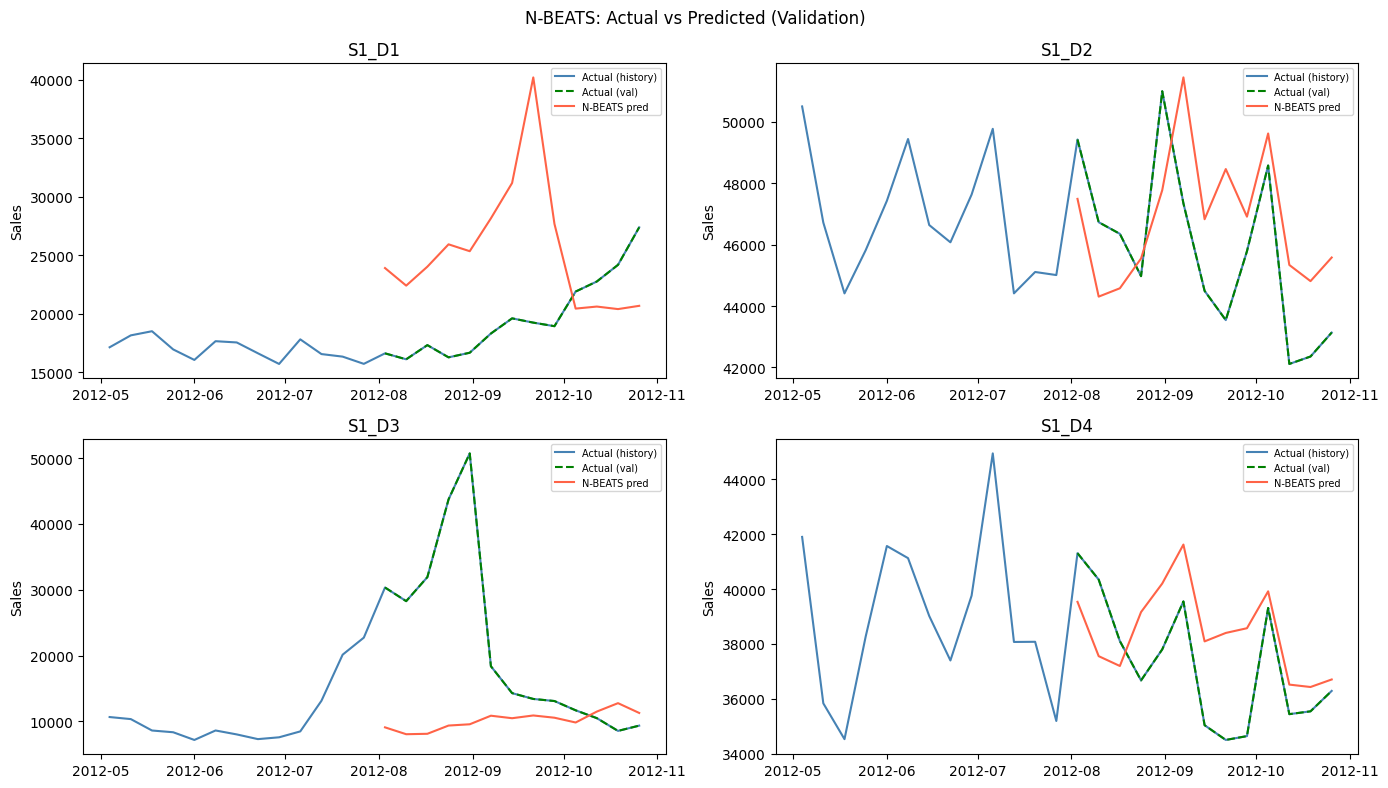

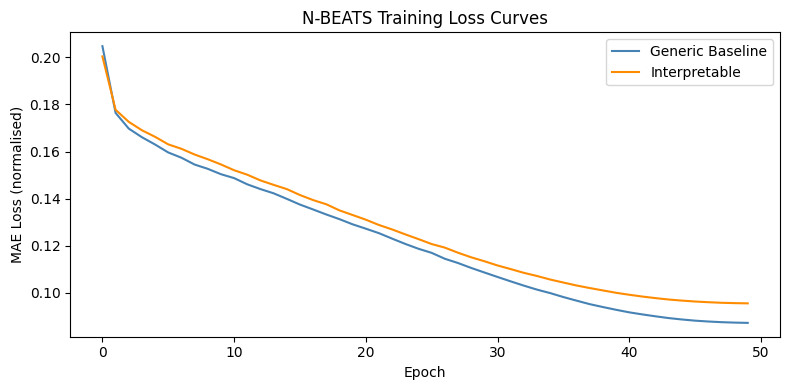

🏃 View run NBEATS_Final at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5/runs/3abb13503a2c459ea8eb39186ae8acd7
🧪 View experiment at: https://dagshub.com/sansi23/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/5
Plots logged.


In [30]:
final_model.eval()
sample_pairs = list(valid_pairs)[:4]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (store, dept) in zip(axes.flat, sample_pairs):
    history = (
        train_filtered[(train_filtered.Store == store) & (train_filtered.Dept == dept)]
        .sort_values('Date')
    )
    val_gt = df_val[(df_val.Store == store) & (df_val.Dept == dept)].sort_values('Date')

    tail    = history['Weekly_Sales'].values.astype(np.float32)
    x_raw   = tail[-INPUT_SIZE:]
    scale   = x_raw.mean() if x_raw.mean() > 1 else 1.0
    x_in    = torch.tensor(x_raw / scale, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_norm = final_model(x_in).squeeze(0).cpu().numpy()
    pred_sales = np.clip(pred_norm * scale, 0, None)

    ax.plot(history['Date'].values[-26:], tail[-26:], label='Actual (history)', color='steelblue')
    if len(val_gt):
        ax.plot(val_gt['Date'].values, val_gt['Weekly_Sales'].values,
                label='Actual (val)', color='green', linestyle='--')
        ax.plot(val_gt['Date'].values[:HORIZON], pred_sales[:len(val_gt)],
                label='N-BEATS pred', color='tomato')
    ax.set_title(f'S{store}_D{dept}')
    ax.legend(fontsize=7)
    ax.set_ylabel('Sales')

plt.suptitle('N-BEATS: Actual vs Predicted (Validation)', fontsize=12)
plt.tight_layout()
plt.savefig('nbeats_forecasts.png', dpi=100)
plt.show()

# loss curve
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(hist_baseline['train_loss'], label='Generic Baseline', color='steelblue')
ax2.plot(hist_interp['train_loss'],   label='Interpretable',    color='darkorange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE Loss (normalised)')
ax2.set_title('N-BEATS Training Loss Curves')
ax2.legend()
plt.tight_layout()
plt.savefig('nbeats_loss_curves.png', dpi=100)
plt.show()

with mlflow.start_run(run_id=final_run_id):
    mlflow.log_artifact('nbeats_forecasts.png')
    mlflow.log_artifact('nbeats_loss_curves.png')
print("Plots logged.")